In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder


In [6]:
df_train = pd.read_parquet('train.parquet')
df_test = pd.read_parquet('test.parquet')

In [7]:
# df_user = df_train.groupby('userId').agg(
#     churn_flag=('churn_flag', 'max'),
#     pages=('page', lambda x: list(x))
# )

# all_pages = ['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 
#              'Add Friend', 'Thumbs Down', 'Add to Playlist', 'Logout',
#              'About', 'Settings', 'Save Settings', 'Cancel', 
#              'Cancellation Confirmation', 'Submit Downgrade', 'Roll Advert',
#              'Upgrade', 'Error', 'Submit Upgrade']

# for p in all_pages:
#     df_user[p] = df_user['pages'].apply(lambda x: int(p in x))

# X = df_user[all_pages]
# y = df_user['churn_flag']

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X, y)

# coef_table = pd.DataFrame({
#     'page': X.columns,
#     'coef': clf.coef_[0],
#     'odds_ratio': np.exp(clf.coef_[0])
# }).sort_values('odds_ratio', ascending=False)

# print(coef_table)

In [8]:
# Weights from Logistic Regression model (Done above)
churn_pages = {
    'Cancel': 7,
    'Cancellation Confirmation': 7,
    'Downgrade': 0.16,
    'Submit Upgrade': 0.14,
    'Upgrade': 0.03,
    'Settings': 0.02,
    'Submit Downgrade': 0.01
}

retain_pages = {
    'Save Settings': -0.0007,
    'Thumbs Down': -0.016,
    'About': -0.054,
    'Help': -0.058,
    'Add Friend': -0.158,
    'Add to Playlist': -0.383,
    'Roll Advert': -0.422,
    'Thumbs Up': -0.716,
    'Home': -1.423,
    'NextSong': -1.925
}

def compute_cumulative_risk(user_df):
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
        
    for page in user_df['page']:
        churn_score += churn_pages.get(page, 0)
        not_churn_score += retain_pages.get(page, 0)
        churn_list.append(churn_score)
        not_churn_list.append(not_churn_score)
        
    user_df['churn_risk_score'] = churn_list
    user_df['not_churn_score'] = not_churn_list
    return user_df



def feature_engineering(df, sequence_features=None):
    df['churn_flag'] = ((df['auth'] == 'Cancelled') | 
                        (df['page'] == 'Cancellation Confirmation')).astype(int)
    
    df['ts'] = pd.to_datetime(df['ts'], unit='ms')
    df = df.sort_values(['userId', 'ts'])
    
    df['churn_risk_score'] = 0.0
    df['not_churn_score'] = 0.0
    df['level'] = df['level'].map({'free': 0, 'paid': 1})
    df['timeInSession'] = df.groupby('userId')['ts'].transform(lambda x: (x - x.min()).dt.total_seconds())

    feats_kept = ['status', 'level', 'userId', 'ts', 
                  'itemInSession', 'time', 'registration', 
                  'not_churn_score', 'churn_risk_score', 'timeInSession']
    
    
    df = df.groupby('userId').apply(compute_cumulative_risk)
    df_seq = df[feats_kept + ['churn_flag']].copy()

    
    return df_seq

In [9]:
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_42908/25692136.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('userId').apply(compute_cumulative_risk)
/var/folders/rr/hj2x23vn64g9m265fnm93yd40000gn/T/ipykernel_42908/25692136.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('userId').apply(compute_cumulative_risk)


In [11]:
df_train.head()

,status,level,userId,ts,itemInSession,time,registration,not_churn_score,churn_risk_score,timeInSession,churn_flag
0,200,0,1000025,2018-10-02 08:59:29,0,2018-10-02 08:59:29,2018-07-10 09:30:08,-1.423,0.0,0.0,0
1,200,0,1000025,2018-10-02 09:02:44,1,2018-10-02 09:02:44,2018-07-10 09:30:08,-3.348,0.0,195.0,0
2,200,0,1000025,2018-10-02 09:06:55,2,2018-10-02 09:06:55,2018-07-10 09:30:08,-5.273,0.0,446.0,0
3,200,0,1000025,2018-10-02 09:10:38,3,2018-10-02 09:10:38,2018-07-10 09:30:08,-7.198,0.0,669.0,0
4,200,0,1000025,2018-10-02 09:13:51,4,2018-10-02 09:13:51,2018-07-10 09:30:08,-9.123,0.0,862.0,0


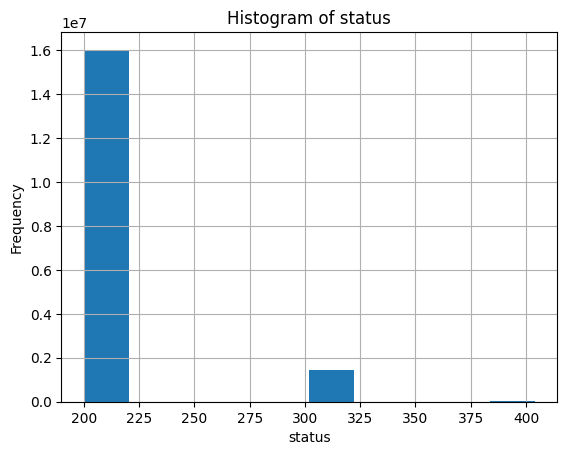

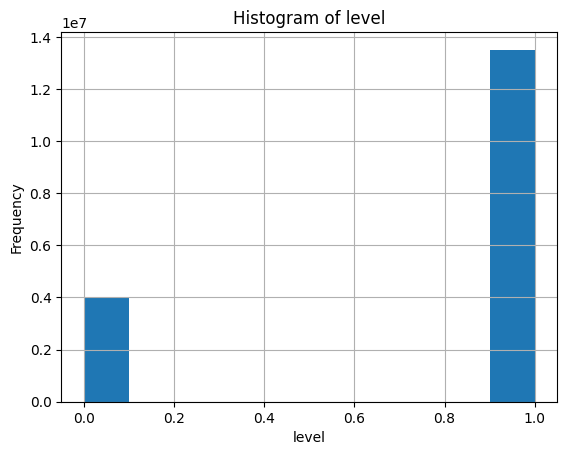

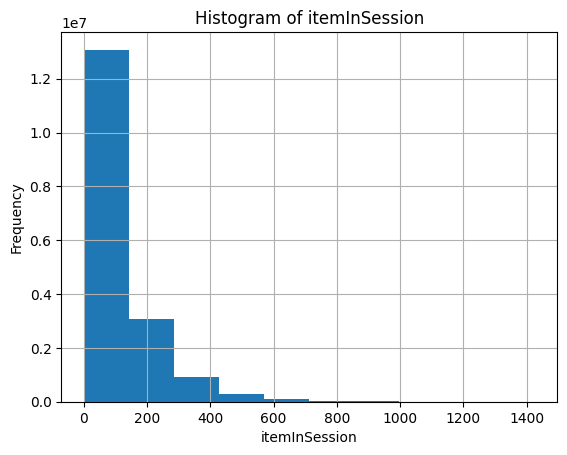

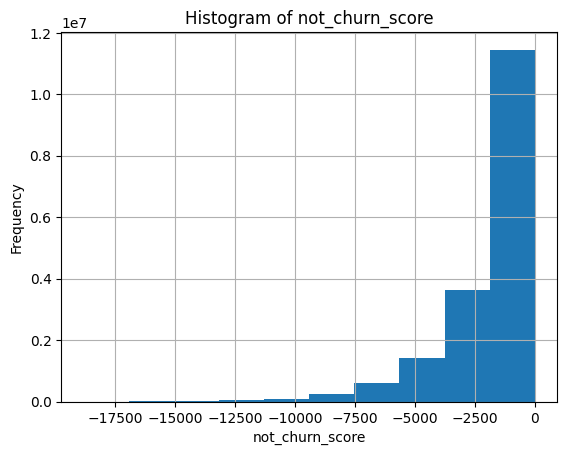

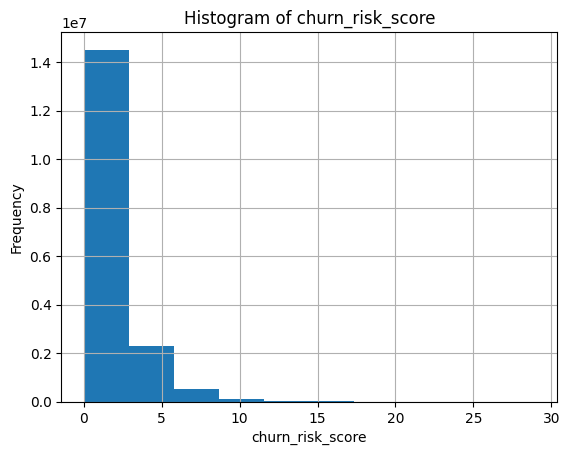

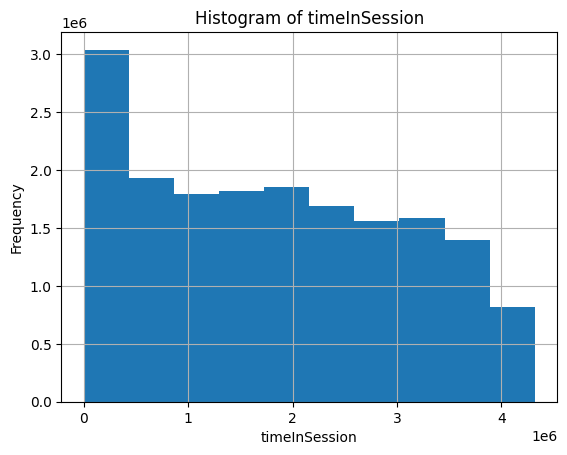

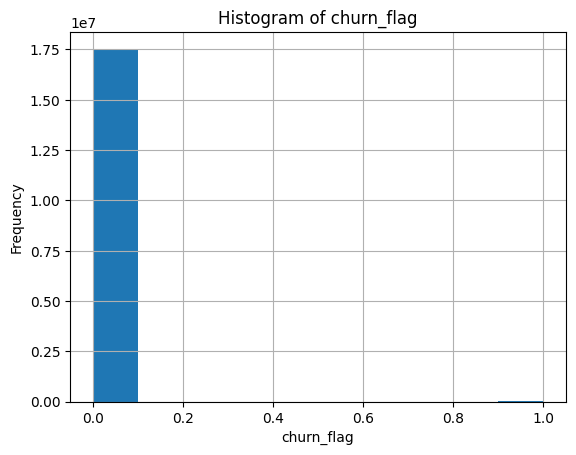

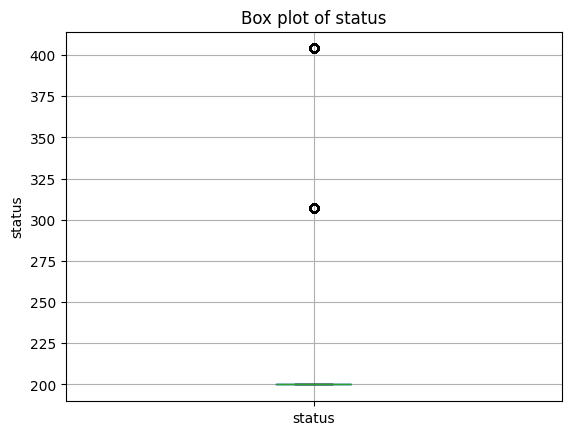

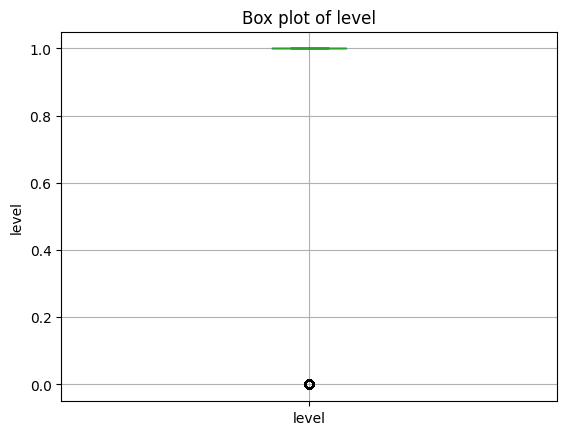

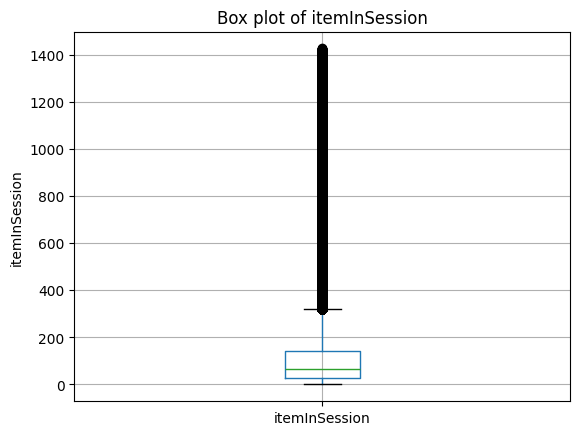

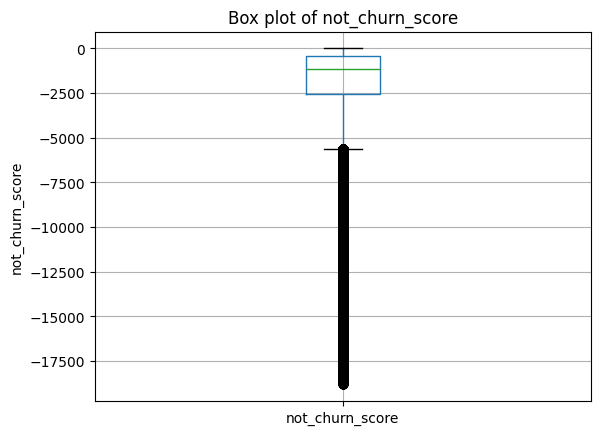

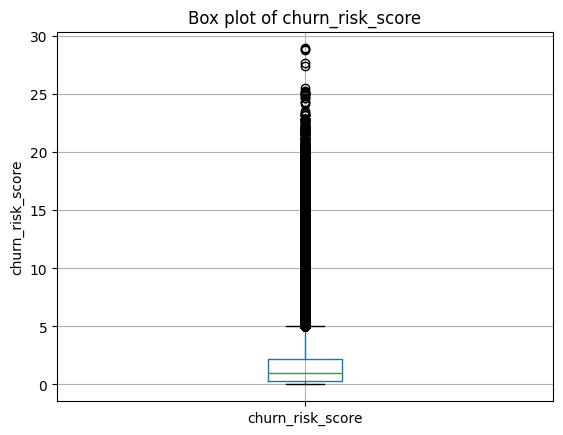

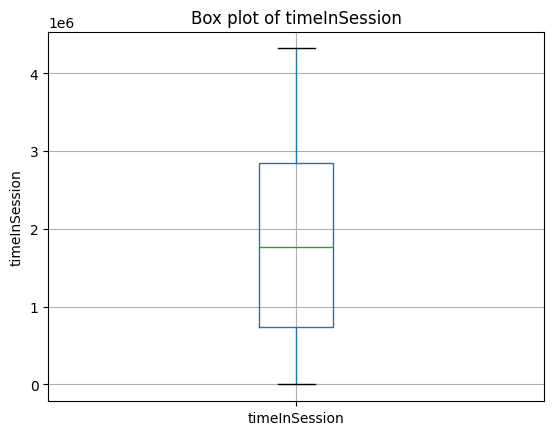

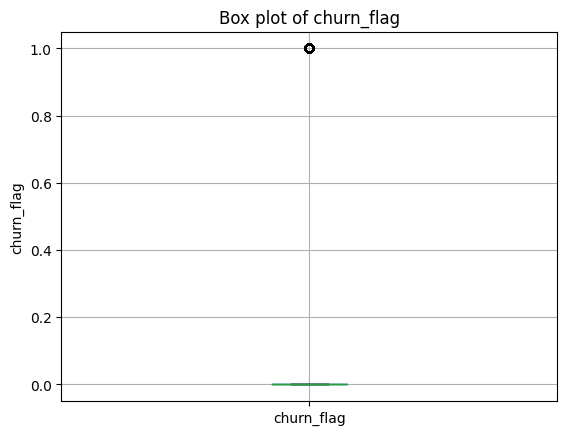

In [12]:
# Basic and Naive EDA
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# Histograms
for col in num_cols:
    plt.figure()
    df_train[col].hist()
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Box plots
for col in num_cols:
    plt.figure()
    df_train.boxplot(column=col)
    plt.title(f"Box plot of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
y = df_train['churn_flag']
X = df_train.drop(columns=['churn_flag', 'userId', 'ts'])fghj

